# Nama: Muhammad Kaisar Novrenza
# NIM: 2602113546

# NO 1.A

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Exploratory Data Analysis(EDA)

In [4]:
df = pd.read_csv("data_C.csv")
df.head(5)

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,...,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,...,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,...,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard
3,3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,...,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488267585,Low_spent_Large_value_payments,391.890332,Standard
4,4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,...,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


In [7]:
df.shape

(25000, 29)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22570 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21164 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [9]:
df.describe()

,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month,Monthly_Balance
count,25000.000000,21164.000000,25000.000000,25000.000000,25000.000000,25000.000000,24528.000000,25000.000000,25000.000000,24699.000000
mean,12499.500000,4189.505970,18.075360,22.238000,75.407480,20.988400,28.449976,32.277257,1465.714590,403.454486
std,7217.022701,3208.575501,122.375374,126.156225,478.786499,14.851345,197.078633,5.126823,8514.582351,215.613056
min,0.000000,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.100770,0.000000,0.088628
25%,6249.750000,1611.188333,3.000000,4.000000,8.000000,10.000000,3.000000,28.043382,30.181528,269.935928
50%,12499.500000,3071.424583,6.000000,5.000000,14.000000,18.000000,6.000000,32.309314,68.248891,335.519841
75%,18749.250000,5941.093333,7.000000,7.000000,20.000000,28.000000,9.000000,36.488060,159.990097,472.202042
max,24999.000000,15204.633333,1789.000000,1498.000000,5797.000000,67.000000,2592.000000,50.000000,82331.000000,1564.134826


## Feature Engineering

In [10]:
df.isnull().sum().sort_values(ascending=False)

Monthly_Inhand_Salary       3836
Type_of_Loan                2852
Name                        2430
Credit_History_Age          2240
Num_of_Delayed_Payment      1792
Amount_invested_monthly     1134
Num_Credit_Inquiries         472
Monthly_Balance              301
Age                            0
Month                          0
Unnamed: 0                     0
Customer_ID                    0
ID                             0
Interest_Rate                  0
Num_Credit_Card                0
Num_Bank_Accounts              0
Annual_Income                  0
SSN                            0
Occupation                     0
Delay_from_due_date            0
Num_of_Loan                    0
Outstanding_Debt               0
Credit_Mix                     0
Changed_Credit_Limit           0
Credit_Utilization_Ratio       0
Total_EMI_per_month            0
Payment_of_Min_Amount          0
Payment_Behaviour              0
Credit_Score                   0
dtype: int64

In [13]:
df = df.drop(columns=[col for col in df.columns if "ID" in col or "Unnamed" in col], errors='ignore')

In [14]:
df['Credit_Score'].value_counts()
X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']
le = LabelEncoder()
y = le.fit_transform(y)
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

In [15]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

In [16]:
for col in categorical_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

## Logistic Regression

In [18]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.587
              precision    recall  f1-score   support

           0       0.49      0.28      0.36       890
           1       0.61      0.42      0.50      1454
           2       0.60      0.78      0.68      2656

    accuracy                           0.59      5000
   macro avg       0.56      0.49      0.51      5000
weighted avg       0.58      0.59      0.57      5000



## Decision Tree

In [19]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.62
              precision    recall  f1-score   support

           0       0.50      0.51      0.50       890
           1       0.59      0.59      0.59      1454
           2       0.68      0.67      0.68      2656

    accuracy                           0.62      5000
   macro avg       0.59      0.59      0.59      5000
weighted avg       0.62      0.62      0.62      5000



## Random Forest

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7404
              precision    recall  f1-score   support

           0       0.64      0.67      0.66       890
           1       0.75      0.71      0.73      1454
           2       0.77      0.78      0.77      2656

    accuracy                           0.74      5000
   macro avg       0.72      0.72      0.72      5000
weighted avg       0.74      0.74      0.74      5000



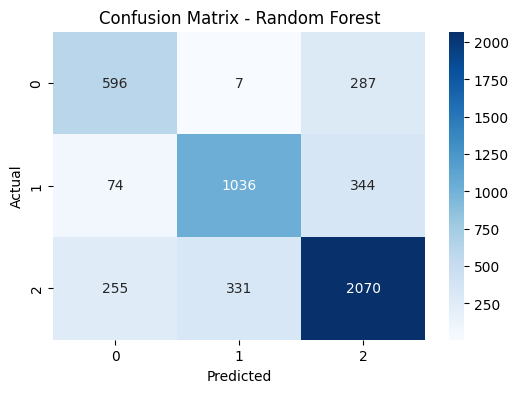

In [21]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The dataset has 25.000 rows and 29 features, the target variable is credit score that has 3 classes which is poor,standard and good. The missing value in the dataset has been handled using median imputation.For the feature engineering are using Label encoding and StandardScaler. I've used 3 models, its Logistic Regression, Decision Tree and Random Forest. The model that have the best performance out of 3 is Random Forest because it can handling a nonlinear relationships. 

For the features that im doing label encoding which is 
Poor = 1
Standard = 2
Good = 3

# No 1.B